# 02. Exploratory Data Analysis (EDA)

This notebook performs comprehensive EDA on the synthetic student data to understand:
- Data distributions
- Feature correlations
- Risk patterns
- Insights for feature engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

In [2]:
# Load data
df = pd.read_csv('../data/raw/synthetic_students.csv')
print(f"Loaded {len(df)} student records")
print(f"Columns: {list(df.columns)}")

Loaded 500 student records
Columns: ['student_id', 'student_name', 'attendance_percentage', 'internal_marks', 'assignment_submission_rate', 'semester', 'risk_score', 'risk_level']


## 1. Data Overview

In [3]:
# First few rows
df.head()

,student_id,student_name,attendance_percentage,internal_marks,assignment_submission_rate,semester,risk_score,risk_level
0,STU0001,Allison Hill,84.9,98.5,66.5,2,28.55,Low
1,STU0002,Noah Rhodes,70.3,100.0,64.1,1,26.72,Low
2,STU0003,Angie Henderson,65.6,79.4,83.6,5,20.61,Low
3,STU0004,Daniel Wagner,79.8,52.5,22.2,4,37.00,Moderate
4,STU0005,Cristian Santos,54.7,68.4,77.9,4,21.06,Low


In [4]:
# Data types and missing values
print("\nData Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  500 non-null    str    
 1   student_name                500 non-null    str    
 2   attendance_percentage       500 non-null    float64
 3   internal_marks              500 non-null    float64
 4   assignment_submission_rate  500 non-null    float64
 5   semester                    500 non-null    int64  
 6   risk_score                  500 non-null    float64
 7   risk_level                  500 non-null    str    
dtypes: float64(4), int64(1), str(3)
memory usage: 31.4 KB
None

Missing Values:
student_id                    0
student_name                  0
attendance_percentage         0
internal_marks                0
assignment_submission_rate    0
semester                      0
risk_score                    0
risk_level          

In [5]:
# Statistical summary
df.describe()

,attendance_percentage,internal_marks,assignment_submission_rate,semester,risk_score
count,500.000000,500.000000,500.00000,500.000000,500.000000
mean,74.685200,85.144800,69.85260,4.458000,22.591040
std,16.913725,13.452133,22.12214,2.249969,14.840691
min,22.000000,32.000000,0.00000,1.000000,-17.470000
25%,62.700000,76.100000,54.47500,2.000000,11.950000
50%,75.950000,87.300000,71.55000,4.000000,21.730000
75%,87.650000,97.250000,87.47500,6.250000,32.290000
max,100.000000,100.000000,100.00000,8.000000,70.540000


## 2. Target Variable Analysis

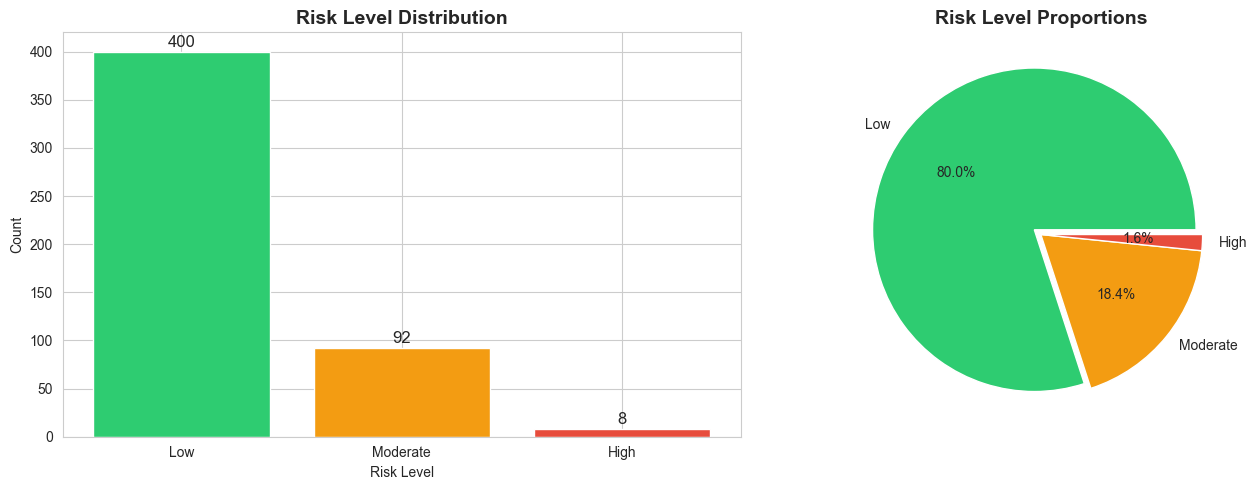

Risk Level Distribution:
  Low: 400 (80.0%)
  Moderate: 92 (18.4%)
  High: 8 (1.6%)


In [6]:
# Risk level distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
ax1 = axes[0]
risk_dist = df['risk_level'].value_counts()
colors = {'Low': '#2ecc71', 'Moderate': '#f39c12', 'High': '#e74c3c'}
bars = ax1.bar(risk_dist.index, risk_dist.values, color=[colors[x] for x in risk_dist.index])
ax1.set_title('Risk Level Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Risk Level')
ax1.set_ylabel('Count')
for bar, count in zip(bars, risk_dist.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             str(count), ha='center', va='bottom', fontsize=12)

# Pie chart
ax2 = axes[1]
ax2.pie(risk_dist.values, labels=risk_dist.index, autopct='%1.1f%%', 
        colors=[colors[x] for x in risk_dist.index], explode=(0.05, 0, 0))
ax2.set_title('Risk Level Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Risk Level Distribution:")
for level, count in risk_dist.items():
    print(f"  {level}: {count} ({count/len(df)*100:.1f}%)")

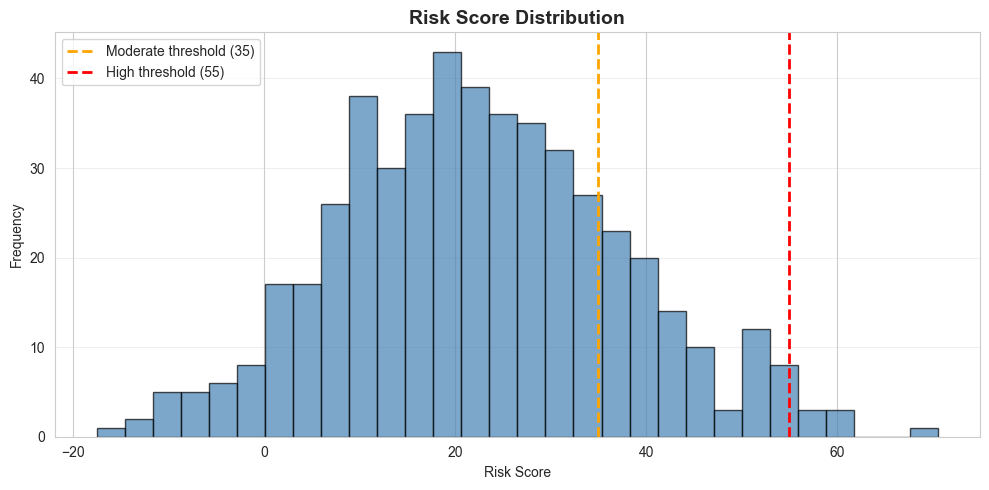

In [7]:
# Risk score distribution
plt.figure(figsize=(10, 5))
plt.hist(df['risk_score'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(x=35, color='orange', linestyle='--', linewidth=2, label='Moderate threshold (35)')
plt.axvline(x=55, color='red', linestyle='--', linewidth=2, label='High threshold (55)')
plt.xlabel('Risk Score')
plt.ylabel('Frequency')
plt.title('Risk Score Distribution', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/risk_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Feature Distributions

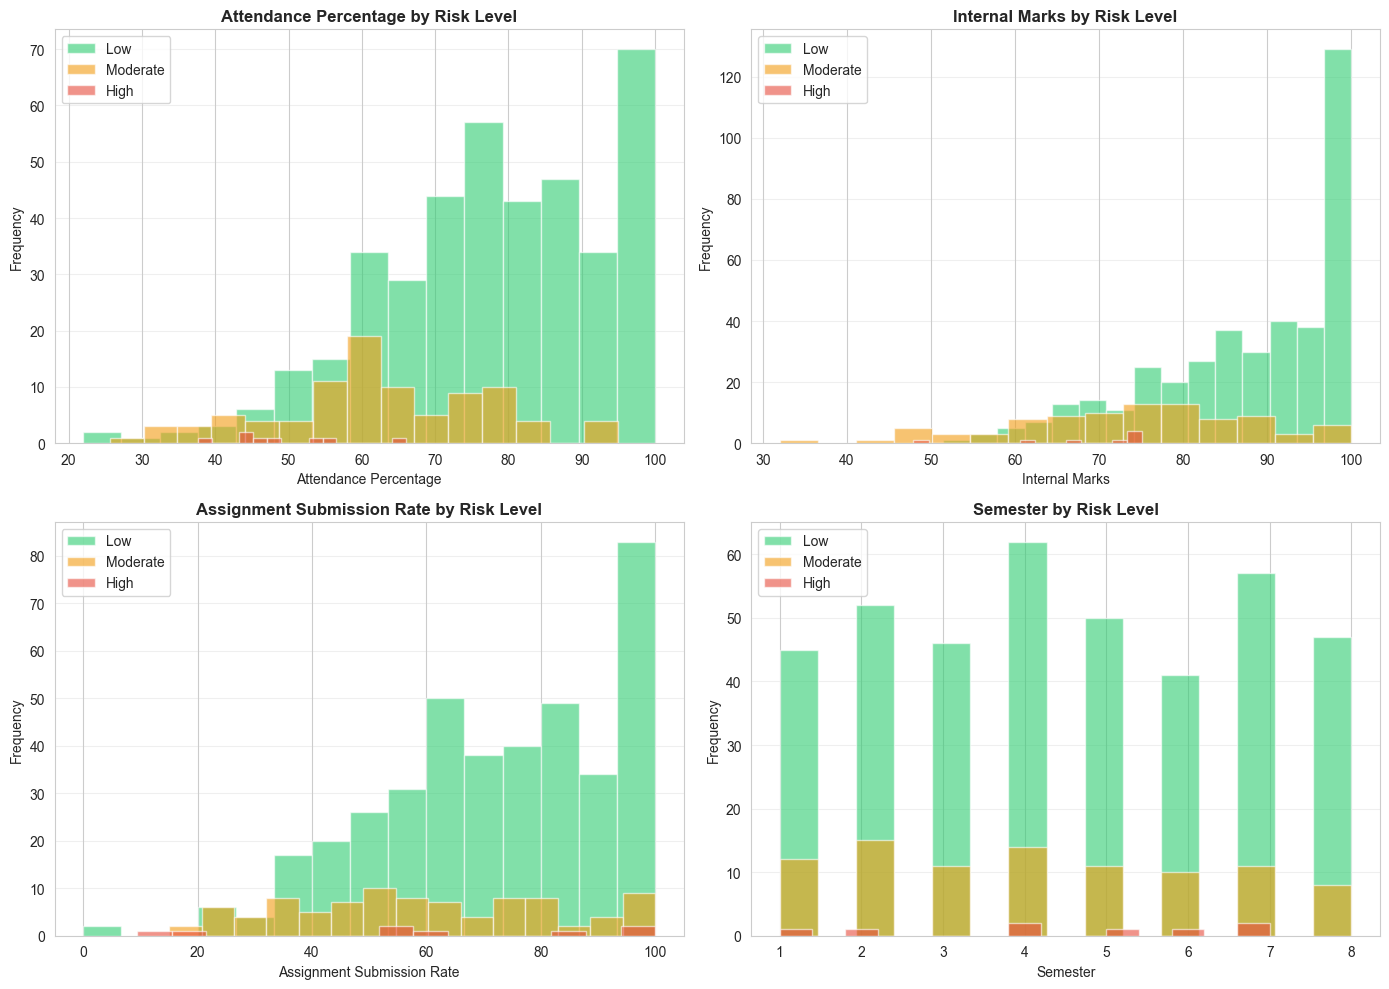

In [8]:
# Distribution of each feature by risk level
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

features = [
    ('attendance_percentage', 'Attendance Percentage'),
    ('internal_marks', 'Internal Marks'),
    ('assignment_submission_rate', 'Assignment Submission Rate'),
    ('semester', 'Semester')
]

for ax, (col, name) in zip(axes.flatten(), features):
    for level in ['Low', 'Moderate', 'High']:
        subset = df[df['risk_level'] == level]
        ax.hist(subset[col], bins=15, alpha=0.6, label=level, color=colors[level])
    ax.set_xlabel(name)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{name} by Risk Level', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/feature_distributions_by_risk.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/d_/tv2cwk6x1w9dfjyttj4kppxh0000gn/T/ipykernel_13348/377501170.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Low', 'Moderate', 'High'], patch_artist=True)
/var/folders/d_/tv2cwk6x1w9dfjyttj4kppxh0000gn/T/ipykernel_13348/377501170.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Low', 'Moderate', 'High'], patch_artist=True)
/var/folders/d_/tv2cwk6x1w9dfjyttj4kppxh0000gn/T/ipykernel_13348/377501170.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['Low', 'Moderate', 'High'], patch_artist=True)


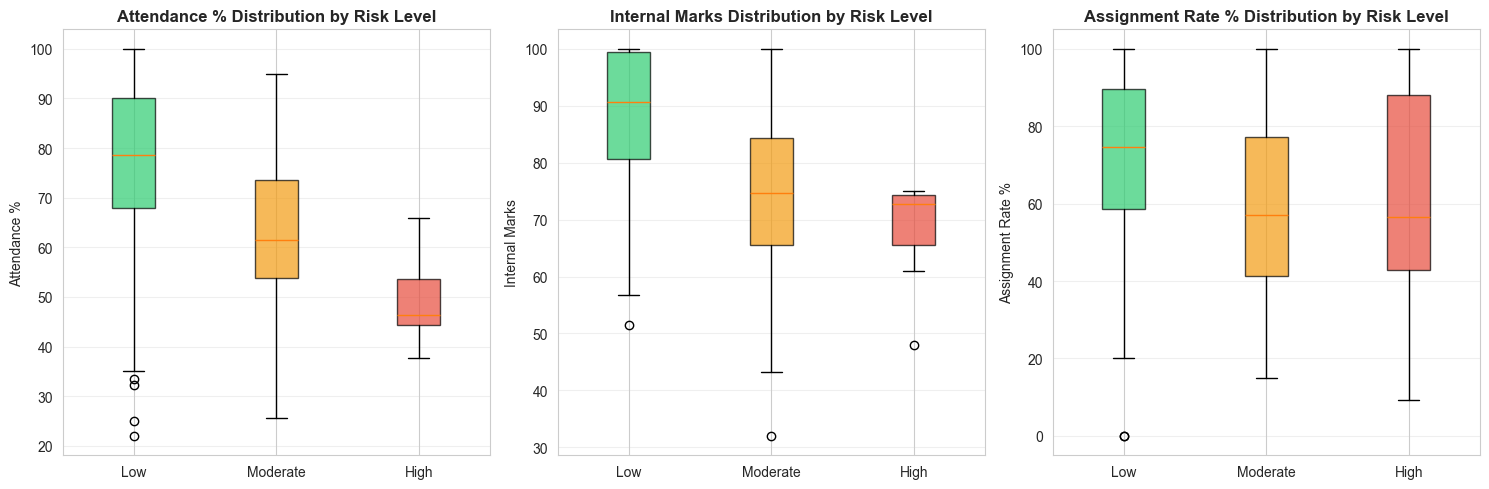

In [9]:
# Box plots for feature comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

features_box = [
    ('attendance_percentage', 'Attendance %'),
    ('internal_marks', 'Internal Marks'),
    ('assignment_submission_rate', 'Assignment Rate %')
]

for ax, (col, name) in zip(axes, features_box):
    data = [df[df['risk_level'] == level][col] for level in ['Low', 'Moderate', 'High']]
    bp = ax.boxplot(data, labels=['Low', 'Moderate', 'High'], patch_artist=True)
    for patch, level in zip(bp['boxes'], ['Low', 'Moderate', 'High']):
        patch.set_facecolor(colors[level])
        patch.set_alpha(0.7)
    ax.set_ylabel(name)
    ax.set_title(f'{name} Distribution by Risk Level', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/boxplots_by_risk.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Correlation Analysis

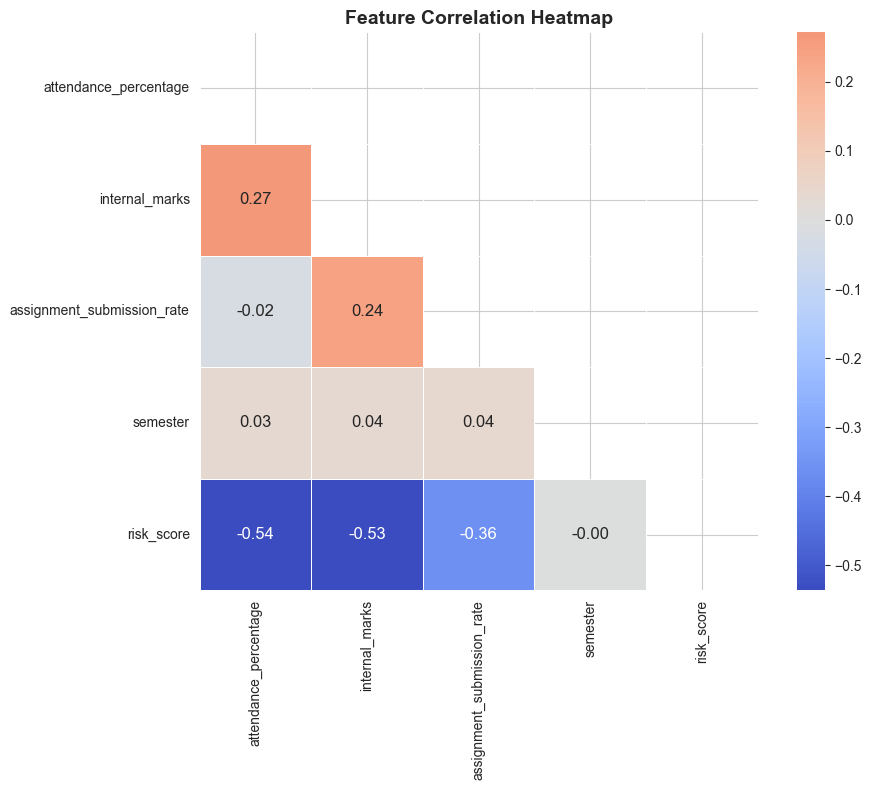


Key Correlations with Risk Score:
  attendance_percentage: -0.54 (Strong negative)
  internal_marks: -0.53 (Strong negative)
  assignment_submission_rate: -0.36 (Moderate negative)
  semester: -0.00 (Weak negative)


In [10]:
# Correlation matrix
corr_cols = ['attendance_percentage', 'internal_marks', 'assignment_submission_rate', 'semester', 'risk_score']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5,
            annot_kws={'size': 12})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Correlations with Risk Score:")
for col in corr_cols:
    if col != 'risk_score':
        corr = corr_matrix.loc[col, 'risk_score']
        strength = 'Strong' if abs(corr) > 0.5 else 'Moderate' if abs(corr) > 0.3 else 'Weak'
        direction = 'negative' if corr < 0 else 'positive'
        print(f"  {col}: {corr:.2f} ({strength} {direction})")

Generating pairplot (this may take a moment)...


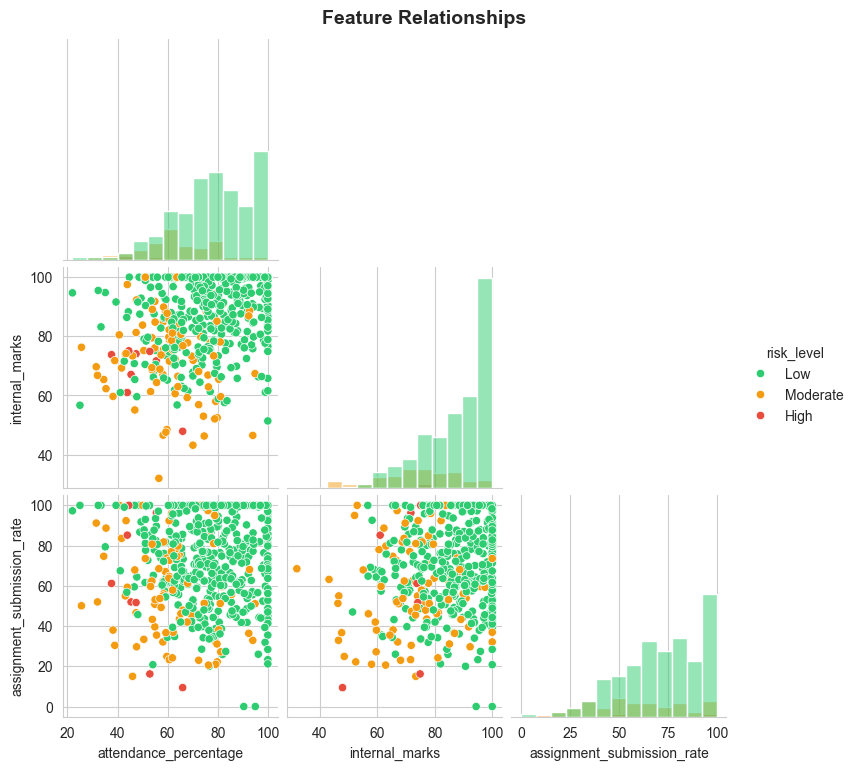

In [11]:
# Pairplot for relationships
print("Generating pairplot (this may take a moment)...")
pair_cols = ['attendance_percentage', 'internal_marks', 'assignment_submission_rate']
g = sns.pairplot(df[pair_cols + ['risk_level']], hue='risk_level', 
                 palette=colors, diag_kind='hist', corner=True)
g.fig.suptitle('Feature Relationships', fontsize=14, fontweight='bold', y=1.02)
plt.savefig('../data/processed/pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Multivariate Analysis

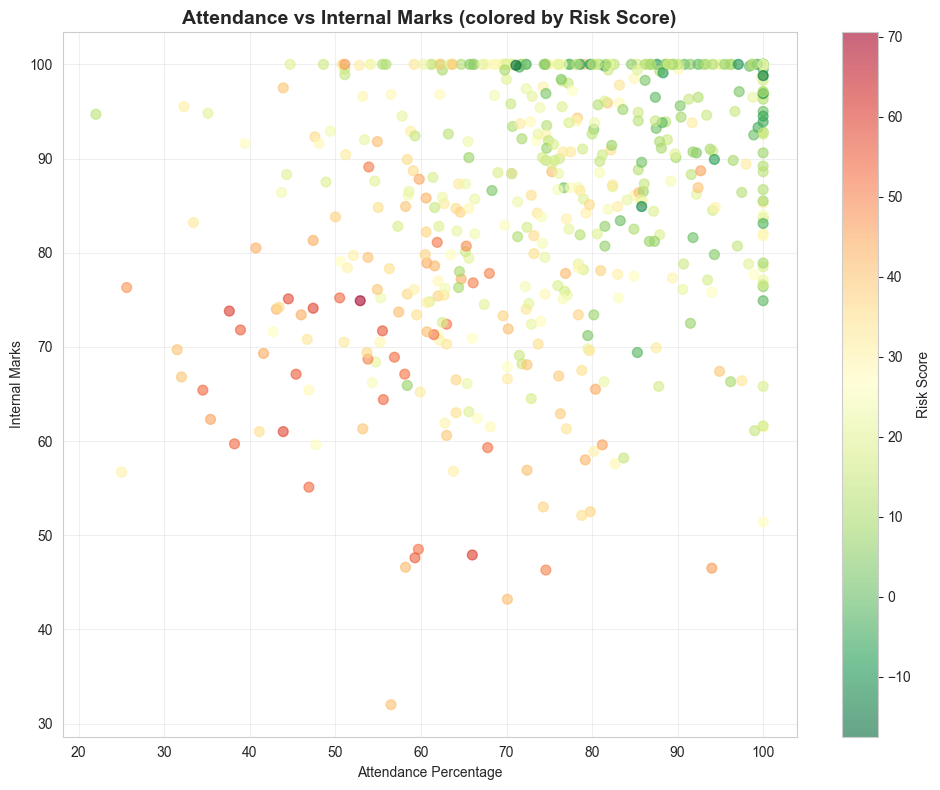

In [12]:
# Scatter: Attendance vs Marks colored by risk
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df['attendance_percentage'], df['internal_marks'], 
                      c=df['risk_score'], cmap='RdYlGn_r', alpha=0.6, s=50)
plt.xlabel('Attendance Percentage')
plt.ylabel('Internal Marks')
plt.title('Attendance vs Internal Marks (colored by Risk Score)', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter)
cbar.set_label('Risk Score', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/attendance_vs_marks.png', dpi=150, bbox_inches='tight')
plt.show()

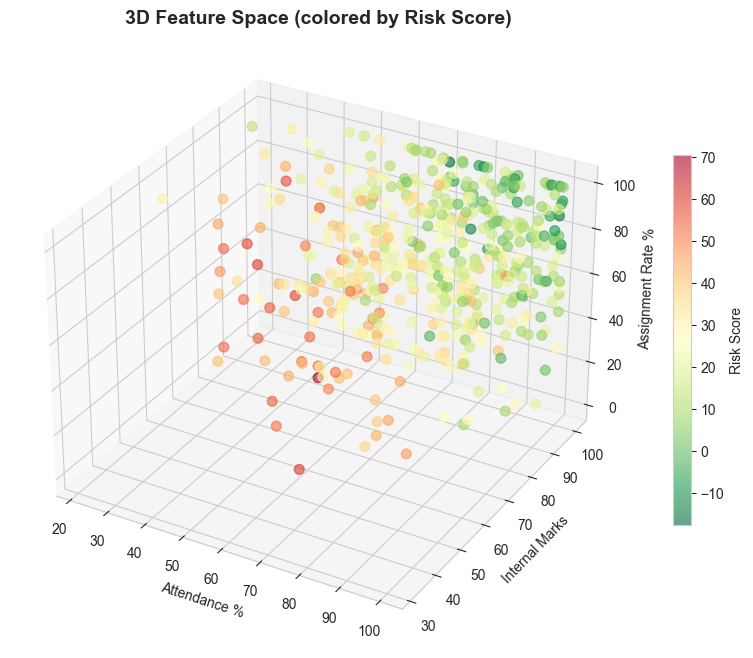

In [13]:
# 3D-style visualization: All three features
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['attendance_percentage'],
    df['internal_marks'],
    df['assignment_submission_rate'],
    c=df['risk_score'],
    cmap='RdYlGn_r',
    alpha=0.6,
    s=50
)

ax.set_xlabel('Attendance %')
ax.set_ylabel('Internal Marks')
ax.set_zlabel('Assignment Rate %')
ax.set_title('3D Feature Space (colored by Risk Score)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Risk Score', shrink=0.6)
plt.savefig('../data/processed/3d_feature_space.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Statistical Insights

In [14]:
# Average features by risk level
print("\n" + "="*60)
print("AVERAGE FEATURES BY RISK LEVEL")
print("="*60)

summary = df.groupby('risk_level')[['attendance_percentage', 'internal_marks', 
                                      'assignment_submission_rate']].mean().round(2)
print(summary)

# Save summary
summary.to_csv('../data/processed/feature_summary_by_risk.csv')
print("\nSummary saved to: ../data/processed/feature_summary_by_risk.csv")


AVERAGE FEATURES BY RISK LEVEL
            attendance_percentage  internal_marks  assignment_submission_rate
risk_level                                                                   
High                        49.15           68.20                       59.00
Low                         78.02           88.10                       72.53
Moderate                    62.41           73.75                       59.14

Summary saved to: ../data/processed/feature_summary_by_risk.csv


In [15]:
# Detailed high-risk student profile
high_risk = df[df['risk_level'] == 'High']

print("\n" + "="*60)
print("HIGH-RISK STUDENT PROFILE")
print("="*60)
print(f"\nTotal High-Risk Students: {len(high_risk)} ({len(high_risk)/len(df)*100:.1f}%)")
print(f"\nAverage Metrics:")
print(f"  Attendance: {high_risk['attendance_percentage'].mean():.1f}%")
print(f"  Internal Marks: {high_risk['internal_marks'].mean():.1f}")
print(f"  Assignment Rate: {high_risk['assignment_submission_rate'].mean():.1f}%")
print(f"  Average Risk Score: {high_risk['risk_score'].mean():.2f}")

print(f"\nPercentile Thresholds (High Risk):")
print(f"  25th percentile Attendance: {df['attendance_percentage'].quantile(0.25):.1f}%")
print(f"  25th percentile Marks: {df['internal_marks'].quantile(0.25):.1f}")
print(f"  25th percentile Assignment: {df['assignment_submission_rate'].quantile(0.25):.1f}%")


HIGH-RISK STUDENT PROFILE

Total High-Risk Students: 8 (1.6%)

Average Metrics:
  Attendance: 49.2%
  Internal Marks: 68.2
  Assignment Rate: 59.0%
  Average Risk Score: 59.67

Percentile Thresholds (High Risk):
  25th percentile Attendance: 62.7%
  25th percentile Marks: 76.1
  25th percentile Assignment: 54.5%


## 7. Key EDA Findings

In [16]:
# Document key findings
eda_findings = {
    'data_quality': {
        'total_records': len(df),
        'missing_values': df.isnull().sum().to_dict(),
        'class_distribution': df['risk_level'].value_counts().to_dict()
    },
    'key_correlations': {
        'attendance_vs_risk': float(corr_matrix.loc['attendance_percentage', 'risk_score']),
        'marks_vs_risk': float(corr_matrix.loc['internal_marks', 'risk_score']),
        'assignment_vs_risk': float(corr_matrix.loc['assignment_submission_rate', 'risk_score'])
    },
    'high_risk_indicators': [
        'Attendance below 60% is a strong indicator of high risk',
        'Internal marks below 50 strongly correlates with high risk',
        'Assignment submission rate below 50% indicates disengagement',
        'All three features show negative correlation with risk score'
    ],
    'feature_engineering_suggestions': [
        'Create binary flags: low_attendance (<60%), low_marks (<50%), low_assignment (<50%)',
        'Create interaction features: attendance * assignment_rate',
        'Consider binning semester into early (1-2), mid (3-5), late (6-8)'
    ]
}

import json
with open('../data/processed/eda_findings.json', 'w') as f:
    json.dump(eda_findings, f, indent=2)

print("EDA findings saved to: ../data/processed/eda_findings.json")
print("\n" + "="*60)
print("EDA COMPLETE - Visualizations saved to ../data/processed/")
print("="*60)

EDA findings saved to: ../data/processed/eda_findings.json

EDA COMPLETE - Visualizations saved to ../data/processed/
